<a href="https://colab.research.google.com/github/shota-suzuki-1228/cosine_similarity/blob/main/%E6%95%99%E6%9D%90_%E3%82%B3%E3%82%B5%E3%82%A4%E3%83%B3%E9%A1%9E%E4%BC%BC%E5%BA%A6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# モジュールのインストール

https://fasttext.cc/docs/en/english-vectors.html

2017年版のWikipedia、UMBC ウェブベース コーパス、 statmt.org ニュースの データセット (16億トークン) で学習された 100 万単語のベクトルを利用します。

In [1]:
#@title 学習済み埋め込みベクトルのダウンロード
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
!unzip wiki-news-300d-1M.vec.zip
!git clone https://github.com/Michi-123/whiteGPT

--2025-09-27 14:28:32--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.240.184.45, 54.240.184.92, 54.240.184.91, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.240.184.45|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 681808098 (650M) [application/zip]
Saving to: ‘wiki-news-300d-1M.vec.zip’

wiki-news-300d-1M.v 100%[===================>] 650.22M   169MB/s    in 3.9s    

2025-09-27 14:28:36 (167 MB/s) - ‘wiki-news-300d-1M.vec.zip’ saved [681808098/681808098]

Archive:  wiki-news-300d-1M.vec.zip
  inflating: wiki-news-300d-1M.vec   
Cloning into 'whiteGPT'...
remote: Enumerating objects: 1299, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 1299 (delta 84), reused 88 (delta 40), pack-reused 1164 (from 1)
Receiving objects: 100% (1299/1299), 136.87 MiB | 31.66 MiB/s, done.


In [2]:
import numpy as np
from matplotlib import pyplot as plt
from whiteGPT import word2vec

In [19]:
# @markdown ベクトルの読み込み
vec_file_path = '/content/wiki-news-300d-1M.vec' #@param{type:'string'}
vectors = word2vec.load_vectors(vec_file_path)

In [21]:
# ベクトルの表示
vectors['paper']

array([-8.040e-02, -1.922e-01, -3.000e-04,  4.030e-02, -7.660e-02,
       -1.380e-02,  1.816e-01, -1.410e-02, -3.410e-02,  4.620e-02,
        1.583e-01, -1.650e-02, -4.960e-02, -1.444e-01,  5.600e-03,
       -1.008e-01,  5.980e-02, -4.630e-02, -7.650e-02,  6.900e-03,
       -1.139e-01, -4.300e-03,  8.360e-02, -6.390e-02,  1.218e-01,
       -3.410e-02, -2.860e-02,  4.300e-03, -8.100e-03,  1.429e-01,
       -6.200e-03, -1.041e-01,  2.440e-02, -2.800e-03, -1.483e-01,
        1.600e-03,  4.870e-02,  9.700e-02, -5.680e-02,  3.390e-02,
       -8.910e-02, -2.880e-02, -1.500e-02,  4.990e-02,  1.686e-01,
        6.470e-02, -1.750e-02,  5.820e-02,  8.570e-02,  2.973e-01,
       -6.380e-02,  8.300e-03, -6.145e-01, -1.868e-01, -5.430e-02,
        2.930e-02, -4.000e-04,  1.270e-02, -1.500e-02, -7.280e-02,
       -2.700e-02, -6.930e-02,  2.600e-02,  1.448e-01,  6.560e-02,
        7.000e-02,  6.550e-02,  8.700e-03, -2.350e-02,  6.990e-02,
       -1.510e-01, -8.290e-02, -1.106e-01, -8.140e-02, -1.827e

<BarContainer object of 300 artists>

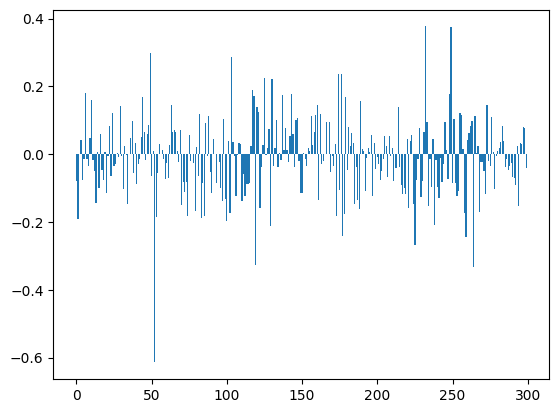

In [22]:
# 埋め込みベクトルのグラフ
labels = np.arange(300)
plt.bar(labels,  vectors['paper'])

# コサイン類似度


$$
\text{cosine_similarity}(A,B)=
\frac{A⋅B}{||A||\space||B||}
​$$


In [24]:
# @title コサイン類似度の計算
import numpy as np

def cosine_similarity(vec1, vec2):
    dot = np.dot(vec1, vec2)
    # Linear algebra（線形代数）ライブラリの利用
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    norm = norm1 * norm2

    similarity = dot / norm

    return similarity

In [10]:
# 適当なテスト用のベクトルを作成
vector1 = np.array([0.1,0.2,0.3])
vector2 = np.array([-0.3,-0.2,-0.1])

# コサイン類似度の計算
similarity = cosine_similarity(vector1, vector2)
print("Cosine Similarity:", similarity)

Cosine Similarity: -0.7142857142857143


In [26]:
vector1 = vectors['paper']
vector2 = vectors['banana']
similarity2 = cosine_similarity(vector1, vector2)
print(similarity2)

0.38695389573492


近いベクトルを抽出

In [35]:
# 基準となるベクトルと他のベクトルとの類似度を調べます。
vector1 = vectors["travel"]

similarities = []

for key, vector2 in vectors.items():
    similarity = cosine_similarity(vector1,vector2)

    # 類似度が0.6超のベクトルを収集
    if similarity > 0.6 :
        similarities.append([similarity, key])

In [36]:
# 収集したベクトルの数
len(similarities)

10

In [37]:
# 類似度の降順で並べ替え
similarities.sort(reverse=True)

In [38]:
# 先頭n件の表示
similarities[:10]

[[np.float64(1.0), 'travel'],
 [np.float64(0.7603609554648685), 'traveling'],
 [np.float64(0.7347434884597059), 'travelling'],
 [np.float64(0.7255005534370903), 'Travel'],
 [np.float64(0.688254091409487), 'travels'],
 [np.float64(0.6665211463234467), 'trip'],
 [np.float64(0.6391544957330975), 'trips'],
 [np.float64(0.6144248363104245), 'journeys'],
 [np.float64(0.6131116626102253), 'traveler'],
 [np.float64(0.6026881236192688), 'journey']]

# ベクトル空間の四則演算の例を確認します

王 - 男 + 女 = 女王？

In [39]:
# king - man + woman
king = vectors["king"]
queen = vectors["queen"]
man = vectors["man"]
woman = vectors["woman"]
cosine_similarity(king - man + woman, queen)

np.float64(0.7673766998589789)

夏 - 暑い + 寒い = 冬？

In [41]:
# 基準となるベクトル
hot = vectors["hot"]
cold = vectors["cold"]
summer = vectors["summer"]
winter = vectors["winter"]

In [42]:
# hot と cold
cosine_similarity(hot, cold)

np.float64(0.712784465178353)

In [45]:
# hot と summer
cosine_similarity(hot, summer)

np.float64(0.4838471573685533)

In [44]:
# summer と winter
cosine_similarity(summer, winter)

np.float64(0.8376738582256028)

In [43]:
# (summer - hot + cold)と winter
cosine_similarity(summer - hot + cold, winter)

np.float64(0.7816870725903828)

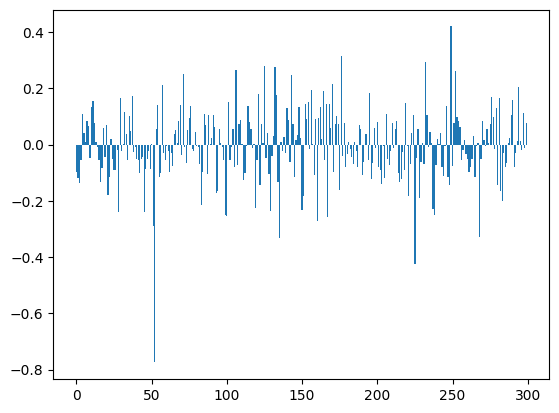

In [47]:
# `hot`ベクトルとは
labels = np.arange(300)
plt.bar(labels, hot)
plt.show()

In [50]:
#@title 特徴ベクトルの作成
def create_feature_vectors(vectors, keys):

    feature_vectors = np.zeros(300)

    for key in keys:
        feature_vectors += vectors[key]

    feature_vectors /= len(keys)

    return feature_vectors

In [49]:
#@title 暑さの特徴ベクトルを見つける

# 暑い（熱い）単語
keys_hot = ['hot', 'boiling', 'beach','heat', 'August', 'burn','swimming']

# 寒い（冷たい）単語
keys_cold = ['cold', 'ice', 'winter', 'frozen', 'water','snow', 'coat','skiing']

# 特徴ベクトルの作成
feature_hot = create_feature_vectors(vectors, keys_hot)
feature_cold = create_feature_vectors(vectors, keys_cold)

In [51]:
# (summer - 暑さの特徴 + 寒さの特徴)と winter
cosine_similarity(summer - feature_hot + feature_cold, winter)

np.float64(0.9076005166652983)

In [52]:
# 温度の特徴ベクトル
temperature = feature_hot - feature_cold

In [53]:
# 本来の暑さとの関係はない（直交ベクトル）
cosine_similarity(temperature , hot)

np.float64(-0.19749000768648328)

<BarContainer object of 300 artists>

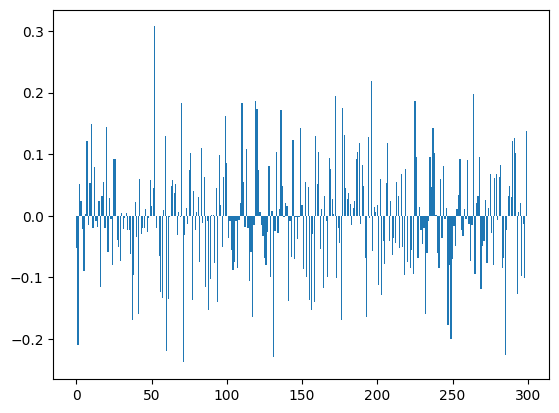

In [55]:
# 温度の特徴ベクトルを可視化
labels = np.arange(300)
plt.bar(labels, temperature)

In [72]:
# @title king - man + woman の例
king = vectors['king']
queen = vectors['queen']

# 男性の特徴
keys_man = ['male','boy','father','brother','beard','prince']
feature_man = create_feature_vectors(vectors, keys_man)

# 女性の特徴
keys_woman = ['female','girl','mother','sister','hair','princess']
feature_woman = create_feature_vectors(vectors, keys_woman)

cosine_similarity(king - feature_man + feature_woman*1.0, queen)

np.float64(0.8366444402338117)

# 同じキーを取り出せるか？

In [76]:
# @title 類似する項目の検索
def search_similar_item(vectors, reference_vector):
    # 初期化
    max_similar_key = None # 最大の類似キー
    max_similarity = -float('inf')  # 最大の類似度
    similarity_list = {} # 類似度の一覧

    # 全てのベクトルに対して、reference_vectorとの類似度を算出します
    for i, key in enumerate(vectors):

        # コサイン類似度の算出
        similarity = cosine_similarity(reference_vector, vectors[key])

        if similarity > 0.6: # 閾値
            similarity_list[key] = similarity

        # 最大値の更新
        if max_similarity < similarity:
            max_similarity = similarity
            max_similar_key = key

    return max_similar_key, max_similarity, similarity_list

In [ ]:
-float('inf')  # 何を足してもマイナス

In [67]:
# summer - feature_hot + feature_cold
reference_vector = summer - feature_hot + feature_cold
key, similarity, similarity_list = search_similar_item(vectors,reference_vector)
print(key)

winter


In [77]:
# king - feature_man + feature_woman
reference_vector = king - feature_man + feature_woman
key, similarity, similarity_list = search_similar_item(vectors, reference_vector)

print(key)
print(similarity_list)

king
{'King': np.float64(0.676404515189219), 'king': np.float64(0.9294387055378409), 'Queen': np.float64(0.630130603867086), 'royal': np.float64(0.6607093628784373), 'kingdom': np.float64(0.680357352355716), 'lady': np.float64(0.6171354471117093), 'queen': np.float64(0.8366444402338117), 'prince': np.float64(0.6408372848982774), 'kings': np.float64(0.7479423603007647), 'ruler': np.float64(0.615835007869579), 'monarch': np.float64(0.7040958906658907), 'princess': np.float64(0.7363794542881361)}


# 地名で検証

In [79]:
tokyo  = vectors["Tokyo"]
france = vectors["France"]
paris = vectors["Paris"]
japan = vectors["Japan"]

In [82]:
# コサイン類似度
cosine_similarity(tokyo - japan + france, paris)

np.float64(0.8581427034450735)

In [83]:
# tokyo - japan + france, paris
reference_vector = tokyo - japan + france
key, similarity, similarity_list = search_similar_item(vectors, reference_vector)

In [85]:
print(key)
print(similarity)
print(similarity_list)

Paris
0.8581427034450735
{'London': np.float64(0.6492047855513082), 'France': np.float64(0.7769600992651912), 'Paris': np.float64(0.8581427034450735), 'Moscow': np.float64(0.6188102119469614), 'Tokyo': np.float64(0.7074563706580035), 'Madrid': np.float64(0.6197539955434832), 'Brussels': np.float64(0.6365837658519494), 'Lyon': np.float64(0.631753234405606), 'Bordeaux': np.float64(0.6409008598843248), 'Marseille': np.float64(0.6422051102056436), 'Toulouse': np.float64(0.6626864245831817), 'Strasbourg': np.float64(0.6166382004080776)}
